# MBA FIAP Inteligência Artificial & Machine Learning

<p align="center">
<img src="images/smart-hiring.jpg">
</p>

## Tecnologia de Processamento de Imagens
## Projeto Final Smart-Hiring: Entrevista Virtual

Este projeto final tem como objetivo explorar os conhecimentos adquiridos nas aulas práticas. Por meio uma trilha guiada para construir uma aplicação que tem por objetivo analisar imagens e extrair uma série de informações que serão utilizadas para compor uma análise de seleção de candidatos para uma entrevista simulada.

Este projeto poderá ser feita por grupos de até 4 pessoas.

| Nome dos Integrantes     | RM            | Turma |
| :----------------------- | :------------ | :---: |
| Alexandre Lima Freitas   | RM 330376     | `1IA` |
| Ewerton Carlos Assis     | RM 330737     | `1IA` |
| Felipe Ribeiro da Silva  | RM 330332     | `1IA` |

Por ser um projeto guiado, fique atento quando houver as marcações **Implementação** indica que é necessário realizar alguma implementação em Python no bloco a seguir onde há a inscrição ```## IMPLEMENTAR``` e **Resposta** indica que é esperado uma resposta objetiva relacionado a algum questionamento. 

**Cada grupo pode utilizar nas respostas objetivas quaisquer itens necessários que enriqueçam seu ponto vista, como gráficos, fotos e, até mesmo, trechos de código-fonte.**

Pode-se utilizar quantos blocos forem necessários para realizar determinadas implementações ou utilizá-las para justificar as respostas. Não é obrigatório utilizar somente o bloco indicado.

Ao final não se esqueça de subir os arquivos do projeto nas contas do GitHub de cada membro, ou subir na do representante do grupo e os membros realizarem o fork do projeto.

A avaliação terá mais ênfase nos seguintes tópicos de desenvolvimento do projeto:
 
1. __Detector de objeto (cartão de identificação)__
2. __Detector de faces__
3. __Detector de sorriso__
4. __Detector de bocejo__
5. __Detector de olhos fechados__
6. __Descritor de objetos na cena__
7. __Conclusões Finais__


## Introdução

_Disclaimer: as informações do caso de uso de negócio são meramente ilustrativas para aplicar as tecnologias de visão computacional de forma mais aderente ao desafio proposto. Todos os comentários foram forjados para dar vazão aos desafios e não representam formas de avaliação de candidatos. A empresa em questão, a Wandee, é fictícia._

A empresa **Wandee**, especializada em entrevistas virtuais, está construindo um produto minimamente viável (MVP) para testar algumas tecnologias voltadas a visão computacional para tornar o processo de seleção, especialmente a etapa de entrevista mais completo, rápido e que permita aos recrutadores obterem feedbacks mais completos além da profunidade técnica de cada posição, como por exemplo, se o candidato é ele mesmo (prova de identidade), se possuí o cartão de acesso a entrevista, aspectos de atenção durante a entrevista, como concentração e foco. Ainda será analisado questões de organização no local do entrevistado, buscando por objetos na visão da câmera.

Todo o processo de entrevista virtual é feito remotamente por meio de uma câmera (_webcam_). Logo, todos os algoritmos desenvolvidos precisam capturar as imagens desta origem.

## 1. Detector de objeto

Antes de começar com o processo de autenticação, os candidatos precisam utilizar o celular e exibir o ícone da empresa para a câmera. Se o resultado for positivo indica que o sistema pode avançar para a próxima etapa.

<p align="center">
<img src="images/logo.png" height="60%" width="60%">
</p>

Construa um algortimo que seja capaz de analisar uma região de interesse específica (ROI, _Region of Interest_), capturada por vídeo, e valide se o ícone está presente ao ser exibido pelo celular do candidato. 

Lembre-se que questões de proporção e rotação precisam ser consideradas na identificação.

Este processo precisa ser de rápida identificação, neste caso não será possível aplicar técnicas que envolvam aprendizado de máquina. É indicado o uso de detectores de objetos e extratores de características.

_No seu smartphone abra o navegador e entre com o link https://raw.githubusercontent.com/michelpf/fiap-ml-tec-proc-imagens-capstone/master/projeto-final/imagens/logo.png_

Ou, escaneie com seu smartphone o QRCode abaixo.

<p align="center">
<img src="images/qrcode.png" height="25%" width="25%">
</p>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
from os import listdir
from os.path import isfile, join
from scipy.spatial import distance as dist
import collections
from matplotlib.pyplot import figure

%matplotlib inline

A função abaixo deve receber uma imagem capturada da região de interesse e comparar com a imagem template do logotipo de empresa. O retorno é o número de correspondências encontradas.

In [2]:
def detector(imagem, template):
    # Conversão da imagem para escala de cinza
    imagem_norm = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
    template_norm = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

    # SOLUCAO A SEGUIR
    FLANN_INDEX_LSH = 6
    orb_detector = cv2.ORB_create()
    kps = orb_detector.detect(imagem_norm, None)
    kps_image, desc_image = orb_detector.compute(imagem_norm, kps)
    kps = orb_detector.detect(template_norm, None)
    kps_template, desc_template = orb_detector.compute(template_norm, kps)
    index_params= dict(algorithm = FLANN_INDEX_LSH, table_number = 12, key_size = 20, multi_probe_level = 2) 
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(desc_image, desc_template, k=2)
    
    return len(matches)

Carregue a imagem de template.

In [5]:
# SOLUCAO A SEGUIR
image_template = cv2.imread("images/logo.png")

Utilize a função ```detector``` para obter as correspondências identificadas. Por meio de testes prévios, estabeleça qual o valor de _matches_ para o template definido. Isto pode fazer com que ajuste valores do detector ORB para ajustes, é um processo de experimentação.

Após definir o limiar, desenvolva uma regra para comparar com o valor de _matches_ e exibir em tempo real se o template foi localizado.

In [2]:
# Função de suporte para exibição de imagens no Jupyter
def exibir_imagem(imagem):
    figure(num=None, figsize=(15, 10))
    image_plt = mpimg.imread(imagem)
    plt.imshow(image_plt)
    plt.axis('off')
    plt.show()

O trecho de códido abaixo é para iniciar a captura de imagens da câmera. Nela será definido uma região de interesse que deverá ser capturado uma imagem para acionar a função de detecção.

In [16]:
cap = cv2.VideoCapture(0)
while True:
    # Obtendo imagem da câmera
    ret, frame = cap.read()
    
    if ret:
        # Definindo região de interesse (ROI)
        height, width = frame.shape[:2]
        top_left_x = int(width / 3)
        top_left_y = int((height / 2) + (height / 4))
        bottom_right_x = int((width / 3) * 2)
        bottom_right_y = int((height / 2) - (height / 4))
    
        # Desenhar retângulo na região de interesse
        cv2.rectangle(frame, (top_left_x,top_left_y), (bottom_right_x,bottom_right_y), 255, 3)

        # Obtendo região de interesse para validação do detector
        cropped = frame[bottom_right_y:top_left_y , top_left_x:bottom_right_x]

        # Executando o detector, definindo um limiar e fazendo a comparação para validar se o logotipo foi detectado
        # SOLUCAO A SEGUIR
        THRESHOLD = 425
        num_matches = detector(cropped, image_template)
        if num_matches >= THRESHOLD:
            cv2.putText(frame, "Matched", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
            EVIDENCE_FILENAME = "images/logo-matched.png"
            if not isfile(EVIDENCE_FILENAME):
                cv2.imwrite(EVIDENCE_FILENAME, frame)

        cv2.imshow("Template identification", frame)
        
    # Se for teclado Enter (tecla 13) deverá sair do loop e encerrar a captura de imagem
    if cv2.waitKey(1) == 13: 
        break

cap.release()
cv2.destroyAllWindows()   

Armazene uma evidência do logotipo detectado, exibindo na imagem a região de interesse com a imagem.

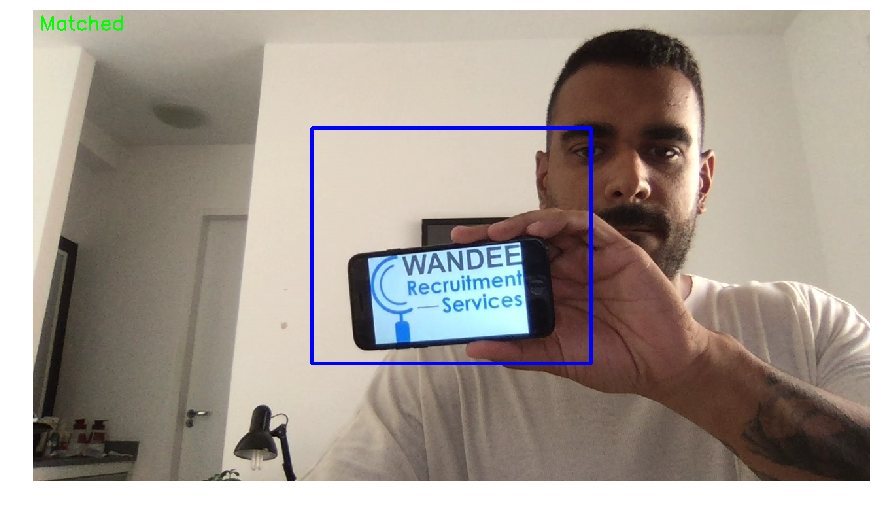

In [17]:
# Passe o parâmetro localização da imagem para exibi-la no notebook
# SOLUCAO A SEGUIR

exibir_imagem("images/logo-matched.png")

## 2. Detector de faces

Para validação de autenticidade do candidado, o processo de entrevista virtual precisa confirmar se a pessoa selecionada para a entrevista é a mesma. Neste caso a técnica a ser utilizada é por meio de um reconhecimento facial,

Inicialmente, precisamos treinar um classificador próprio do OpenCV com exemplos de imagem do candidato.
Eleja uma pessoa do grupo para ser o candidato e treine um conjunto de imagens suficiente para que seja possível alcançar similaridade, onde o valor de não similaridade seja de até 40 pontos. O algortimo de similaridade de faces utiliza um sistema que quando a face é idêntica, o número de pontos é igual a 0, se for totalmente diferente, tende ao infinito. Logo, patamar de 30 a 40 é um bom número de similaridade.

**Implementação**

Nesta etapa inicial será realizado o treinamento das faces de um determinado candidato.
Você precisará coletar um número de imagens relevante do candidato. Além disso, é recomendável aplicação de um detector de faces para que seja extraído somente a _região de interesse_ ou seja, a própria face. Uma maneira de conseguir este tipo de segmentação é utilizando um classificador em cascada de Haar treinado para este fim.

Utilize a função a abaixo para segmentar o rosto de uma imagem.

In [3]:
face_classifier = cv2.CascadeClassifier('classifiers/haarcascade_frontalface_default.xml')

def face_extractor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, 1.2, 5)
    
    if faces is ():
        return None
    
    for (x,y,w,h) in faces:
        cropped_face = img[y:y+h, x:x+w]

    return cropped_face

Crie um algoritmo para que treine um determinado número de faces, escolhido pelo grupo, para que seja armazenado em um diretório específico para posteior treinamento.

In [7]:
cap = cv2.VideoCapture(0)
counter = 0
counter_max = 100

while True:
    ret, frame = cap.read()

    if ret:
        cv2.imshow("Imagem de Treino", frame)
        
        # SOLUCAO A SEGUIR
        filepath = "images/face-recognition/candidate"
        if face_extractor(frame) is not None:
            counter += 1
            face = cv2.resize(face_extractor(frame), (200, 200))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
            full_filename = "{0}/{1:03d}.jpg".format(filepath, counter)
            cv2.imwrite(full_filename, face)
            cv2.putText(face, str(counter), (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
            cv2.imshow('Face {0:03d}'.format(counter), face)
        
        # Se for teclado Enter (tecla 13) deverá sair do loop e encerrar a captura de imagem
        # ou for alcançado a contagem máxima (amostras)
        if cv2.waitKey(1) == 13 or counter == counter_max:
            break
        
cap.release()
cv2.destroyAllWindows()
print("Coleta de amostras completado")

Coleta de amostras completado


O treinamento utilizando é um próprio classificador de faces que o OpenCV possui. Neste caso vamos optar pelo classificador Local Binary Patterns Histograms (LBPH), que para este cenário é o mais adequado.

O grupo pode optar por escolher outros tipos de algoritmos do OpenCV, se desejarem.

In [4]:
# SOLUCAO A SEGUIR
data_path = "images/face-recognition/candidate/"

onlyfiles = [f for f in listdir(data_path) if isfile(join(data_path, f))]
training_data, labels = [], []

for i, files in enumerate(onlyfiles):
    image_path = data_path + onlyfiles[i]
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    training_data.append(image)
    labels.append(0)

# Criando uma matriz da lista de labels
labels = np.asarray(labels, dtype=np.int32)

# Treinamento do modelo
model = cv2.face.LBPHFaceRecognizer_create()
model.train(training_data, labels)

print("Modelo treinado com sucesso.")

# SOLUCAO A SEGUIR
persons = {0: 'Candidate'}

Modelo treinado com sucesso.


Vamos considerar uma classificação com sucesso quando a distândia de predição da face analisada for entre 30 e 40. Os valores de retorno destes classificador não é um índice de confiança.

Quando houver uma deteção dentro da margem de distância, armazene a imagem com o nome "success_candidate.png", constando as informações do nome do candidato e a distância identificada pelo classificador (retorno do método _predict_).

Escreva na tela onde a imagem da câmera é capturada a informação da distância de detecção da face extraída versus a face treinada, emuldure a face num retângulo e, se a face for devidadamente identificada, inclua um texto com a informação "```<Nome do candidato>``` Reconhecido"

In [5]:
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    # SOLUCAO A SEGUIR
    if ret:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_classifier.detectMultiScale(frame_gray, 1.2, 5)
        
        if not len(faces):
            cv2.putText(frame, "Unrecognized", (60,60), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
        for (x,y,w,h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
            face = frame_gray[y:y + h, x:x + w]
            predictions = model.predict(face)
            cv2.putText(frame, "Distance {0}".format(predictions[1]), (25, 25), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
            if predictions[1] >= 30 and predictions[1] <= 40:
                cv2.putText(frame, "Recognized {0}".format(persons[0]), (25, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)                
                EVIDENCE_FILENAME = "images/face-recognition/candidate-matched.png"
                if not isfile(EVIDENCE_FILENAME):
                    cv2.imwrite(EVIDENCE_FILENAME, frame)
        cv2.imshow("Face recognition", frame)
        
        
    # Se for teclado Enter (tecla 13) deverá sair do loop e encerrar a captura de imagem    
    if cv2.waitKey(1) == 13: #13 is the Enter Key
        break
        
cap.release()
cv2.destroyAllWindows()     

Guarde como evidência de classificação bem sucedida, uma imagem capturada da câmera durante o processo.

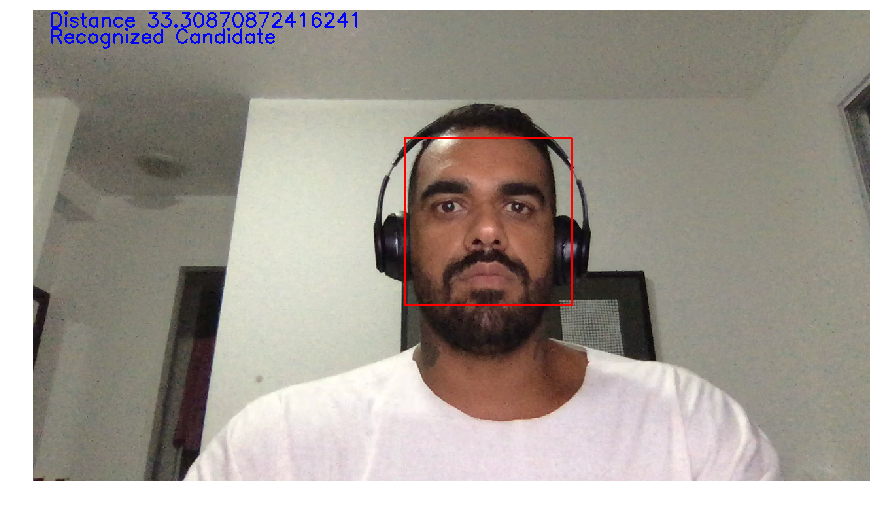

In [6]:
# SOLUCAO A SEGUIR
exibir_imagem("images/face-recognition/candidate-matched.png")

## 3. Detector de sorriso

Muitas empresas demandam que futuros empregados demonstrem educação, tranquilidade e empatia, características que podem ser evidencias com uma uma análise simples da receptividade do candidado por meio das expressões de seu rosto.

Um detector importante disto é sobre se o candidato mantém o semblante fechado ou se mantém um rosto alegre, oscilando sorrisos a medida que é realizada a entrevista e demais questionamentos.

Utilize as bibliotecas do _DLib_, em especial o preditor treinado para 68 pontos de marcação de face, para identificar a geometria dela e obtenha as marcações de interesse.

Uma das formas de extraírmos os pontos de contorno da face é utilizando o modelo do _DLib_ ```shape_predictor_68_face_landmarks.dat```. Este modelo retorna 68 pontos da face

In [3]:
import dlib
import numpy 

predictor_68_path = "models/shape_predictor_68_face_landmarks.dat"

predictor = dlib.shape_predictor(predictor_68_path)
detector = dlib.get_frontal_face_detector()

Liste os pontos de cada parte do rosto. A partir deles poderão ser feitos estudos geométricos para identificar características relcioandos aos mesmos.

In [4]:
# SOLUCAO A SEGUIR
FACE_POINTS = list(range(17, 68))
MOUTH_POINTS = list(range(48, 61))
RIGHT_BROW_POINTS = list(range(17, 22))
LEFT_BROW_POINTS = list(range(22, 27))
RIGHT_EYE_POINTS = list(range(36, 42))
LEFT_EYE_POINTS = list(range(42, 48))
NOSE_POINTS = list(range(27, 35))
JAW_POINTS = list(range(0, 17))

Crie uma função que será utilizada para identificar um sorriso. Leve em consideração estudos que envolvem cálculo de razão de aspecto geométrico e adapte para os pontos dos lábios.

Estude o paper de [Soukupová e Čech de 2016](http://vision.fe.uni-lj.si/cvww2016/proceedings/papers/05.pdf) para entender como obter um cálculo de aspecto de razão para formas geométricas da face. Você pode fazer aproximações a partir do estudo do paper para outras formas, como os lábios e olhos.

Crie uma função ```mouth_aspect_ratio``` que receba os pontos dos lábios e calcule o aspecto de razão para que seja exibida dados de quando a boca está aberta, fechada, dentre outros comportamentos. A função ```eye_aspect_ratio``` é também definida para calcular o aspecto de razão de um dos olhos, a ser utilizada na função ```annotate_landmarks_convex_hull_image```.

In [5]:
# SOLUCOES A SEGUIR

def mouth_aspect_ratio(mouth):
    a = dist.euclidean(mouth[2], mouth[10]) 
    b = dist.euclidean(mouth[4], mouth[8])
    c = dist.euclidean(mouth[1], mouth[11]) 
    d = dist.euclidean(mouth[3], mouth[9])
    e = dist.euclidean(mouth[5], mouth[7])
    f = dist.euclidean(mouth[0], mouth[6])
    mar = (a + b + c + d + e) / (2.0 * f)
    
    return mar


def eye_aspect_ratio(eye):
    a = dist.euclidean(eye[1], eye[5]) 
    b = dist.euclidean(eye[2], eye[4])
    c = dist.euclidean(eye[0], eye[3])
    ear = (a + b) / (2.0 * c)
    
    return ear


Na função abaixo, inclua um segundo retorno que será a razão de aspecto dos lábios. Deixe como está o terceiro retorno, pois ele será estudado no próximo algoritmo.

In [6]:
def annotate_landmarks_convex_hull_image(im):
    im = im.copy()
    rects = detector(im, 1)
    
    if len(rects) == 0:
        return im, 0, 0
    
    landmarks_list = []
    
    for rect in rects:
        landmarks = numpy.matrix([[p.x, p.y] for p in predictor(im, rect).parts()])

        for k, d in enumerate(rects):
            cv2.rectangle(im, (d.left(), d.top()), (d.right(), d.bottom()), (0, 255, 0), 2)

            points = cv2.convexHull(landmarks[NOSE_POINTS])
            cv2.drawContours(im, [points], 0, (0, 255, 0), 1)

            points = cv2.convexHull(landmarks[MOUTH_POINTS])
            cv2.drawContours(im, [points], 0, (0, 255, 0), 1)
            
            points = cv2.convexHull(landmarks[RIGHT_BROW_POINTS])
            cv2.drawContours(im, [points], 0, (0, 255, 0), 1)

            points = cv2.convexHull(landmarks[LEFT_BROW_POINTS])
            cv2.drawContours(im, [points], 0, (0, 255, 0), 1)

            points = cv2.convexHull(landmarks[RIGHT_EYE_POINTS])
            cv2.drawContours(im, [points], 0, (0, 255, 0), 1)
            
            points = cv2.convexHull(landmarks[LEFT_EYE_POINTS])
            cv2.drawContours(im, [points], 0, (0, 255, 0), 1)
            
            mouth_aspect = mouth_aspect_ratio(landmarks[MOUTH_POINTS])
            eye_aspect = eye_aspect_ratio(landmarks[RIGHT_EYE_POINTS])

    return im, mouth_aspect, eye_aspect

Realize ensaios para definir o valor de sorriso versos simulações com os lábios normais e aberto. Um sorriso é uma estado entre os lábios fechados ou semi-fechados e a boca inteiramente aberta.
Definina abaixo os limiares inferior e superior para a identificação de um sorriso.

In [7]:
# SOLUCAO A SEGUIR
smile_min = 0.85
smile_max = 0.95

Após identificar o sorriso, contabilize quantas vezes foram identificados.

In [8]:
smile_cam_capture = cv2.VideoCapture(0)
cv2.destroyAllWindows()

# Quantidade de sorrisos identificados
smile_counter = 0

while True:
    ret, frame = smile_cam_capture.read()

    if ret:
        frame, mouth_aspect, _ = annotate_landmarks_convex_hull_image(frame)
        
        # SOLUCAO A SEGUIR
        smile = mouth_aspect >= smile_min and mouth_aspect <= smile_max
        if smile:
            EVIDENCE_FILENAME = "images/evidence/smile-matched.png"
            if not isfile(EVIDENCE_FILENAME):
                cv2.imwrite(EVIDENCE_FILENAME, frame)
            cv2.putText(frame, "Matched Smile", (25, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
            smile_counter += 1
    
        cv2.putText(frame, "Mouth Aspect: {0}".format(mouth_aspect), (25, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        cv2.putText(frame, "Smile counter: {0}".format(smile_counter), (25, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        cv2.imshow("Smile detector", frame)
        
        # Se for teclado Enter (tecla 13) deverá sair do loop e encerrar a captura de imagem   
        if cv2.waitKey(1) == 13:
            break
    else:
        break
        
smile_cam_capture.release()
cv2.destroyAllWindows()

Armazene um exemplo de uma imagem, na pasta ```images``` com o sorriso detectado para exibição.

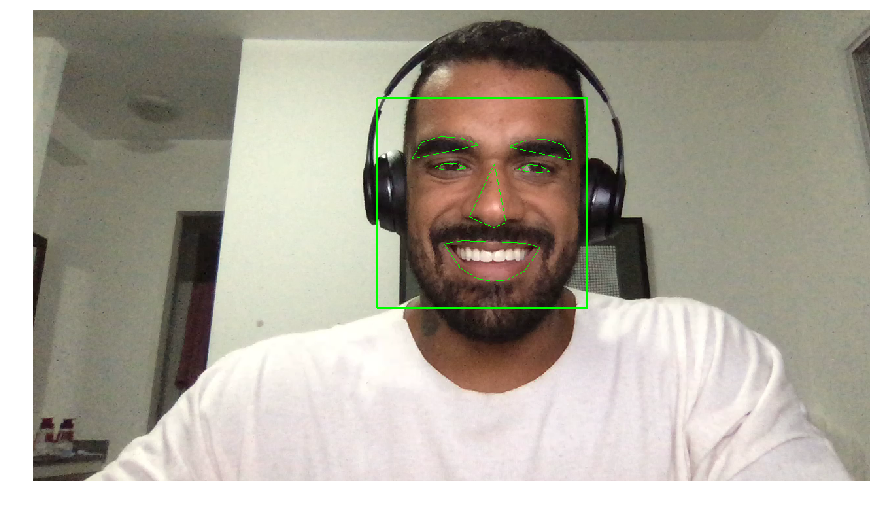

In [9]:
# SOLUCAO A SEGUIR
exibir_imagem("images/evidence/smile-matched.png")

## 4. Detector de bocejos

Os candidados devem estar sempre atentos durante a entrevista virtual. Para garantir que ele se preparou adequadamente antes do início da entrevista não deverá ser tolerado bocejos.

Um detector de bocejos deverá utilizar aspectos das marcações dos lábios já definidas para identificar o bocejo. Neste caso o que será diferente é o valor da razão de aspecto.

Neste caso não há um limiar, como o bocejo é a boca aberta ao máximo, vamos definir um valor mínimo.

In [7]:
# SOLUCAO A SEGUIR
yawn_min = 1.5

In [8]:
yawn_cam_capture = cv2.VideoCapture(0)
cv2.destroyAllWindows()

# Quantidade de bocejos identificados
yawn_counter = 0

while True:
    ret, frame = yawn_cam_capture.read()
    
    if ret:
        frame, mouth_aspect, _ = annotate_landmarks_convex_hull_image(frame)
        
        # SOLUCAO A SEGUIR
        yawn = mouth_aspect >= yawn_min
        if yawn:
            EVIDENCE_FILENAME = "images/evidence/yawn-matched.png"
            if not isfile(EVIDENCE_FILENAME):
                cv2.imwrite(EVIDENCE_FILENAME, frame)
            cv2.putText(frame, "Yawn matched", (25, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
            yawn_counter += 1
    
        cv2.putText(frame, "Mouth Aspect: {0}".format(mouth_aspect), (25, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        cv2.putText(frame, "Yawn counter: {0}".format(yawn_counter), (25, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        cv2.imshow("Yawn detector", frame)
       
        # Se for teclado Enter (tecla 13) deverá sair do loop e encerrar a captura de imagem   
        if cv2.waitKey(1) == 13:
            break
    else:
        break
        
yawn_cam_capture.release()
cv2.destroyAllWindows()

Armazene um exemplo de uma imagem, na pasta ```images``` com o bocejo detectado para exibição.

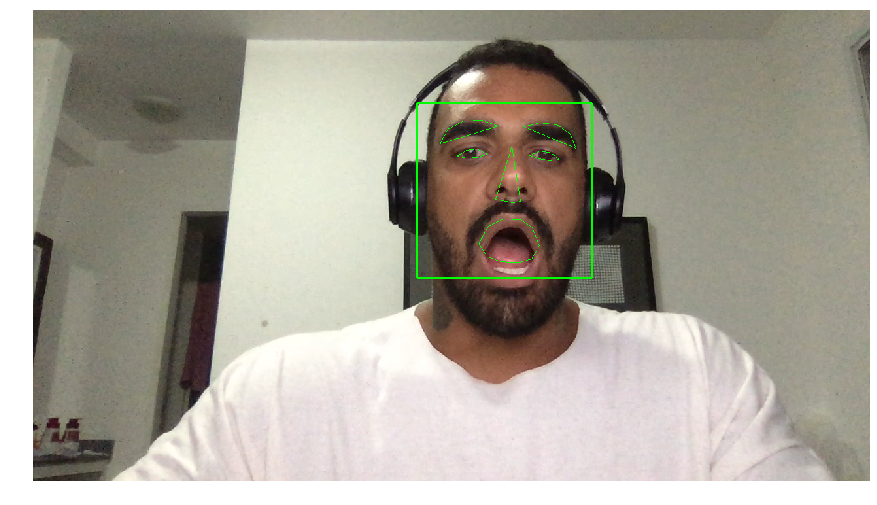

In [4]:
# SOLUCAO A SEGUIR
exibir_imagem("images/evidence/yawn-matched.png")

## 5. Detector de olhos fechados

A atenção durante um processo de entrevista é algo crucial, e mais marcante neste etapa do processo seletivo. Por esta razão é preciso identificar a quantidade de vezes que o entrevistado feche os olhos, para entendermos se ele de fato está atento as perguntas e ao processo como um todo.

Elabore um algoritmo que detecte os olhos fechados e contabilize ao final da transmissão.

Este caso requer um estudo também geométrico que visa analisar os pontos da marcação dos olhos. Para fins de simplificação, podemos adotar um único olho, e a partir dele, estebelecer o razão de aspecto para quando ele está aberto e fechado.

Construa uma função chamada ```eye_aspect_ratio``` para calcular o aspecto de razão de um dos olhos. Altere a função ```annotate_landmarks_convex_hull_image``` para exibir, no terceiro parâmetro, o valor de aspecto de um dos olhos. **Observação**: estes itens foram resolvidos no desafio de número 3. 

No caso do olho, precisamos definir somente um valor máximo de limite.

In [7]:
# SOLUCAO
eye_max = 0.20

In [8]:
eye_cam_capture = cv2.VideoCapture(0)
cv2.destroyAllWindows()

# Quantidade de olhos fechados identificados
closed_eyes_counter = 0

while True:
    ret, frame = eye_cam_capture.read()
    
    if ret:
        frame, _, eye_aspect = annotate_landmarks_convex_hull_image(frame)
        
        closed_eyes = eye_aspect <= eye_max
        if closed_eyes:
            EVIDENCE_FILENAME = "images/evidence/closed-eyes-matched.png"
            if not isfile(EVIDENCE_FILENAME):
                cv2.imwrite(EVIDENCE_FILENAME, frame)
            cv2.putText(frame, "Closed eyes matched", (25, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
            closed_eyes_counter += 1
    
        cv2.putText(frame, "Eye Aspect: {0}".format(eye_aspect), (25, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        cv2.putText(frame, "Closed eyes counter: {0}".format(closed_eyes_counter), (25, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        cv2.imshow("Closed eyes detector", frame)
        
        # Se for teclado Enter (tecla 13) deverá sair do loop e encerrar a captura de imagem  
        if cv2.waitKey(1) == 13:
            break
    else:
        break
        
eye_cam_capture.release()
cv2.destroyAllWindows()

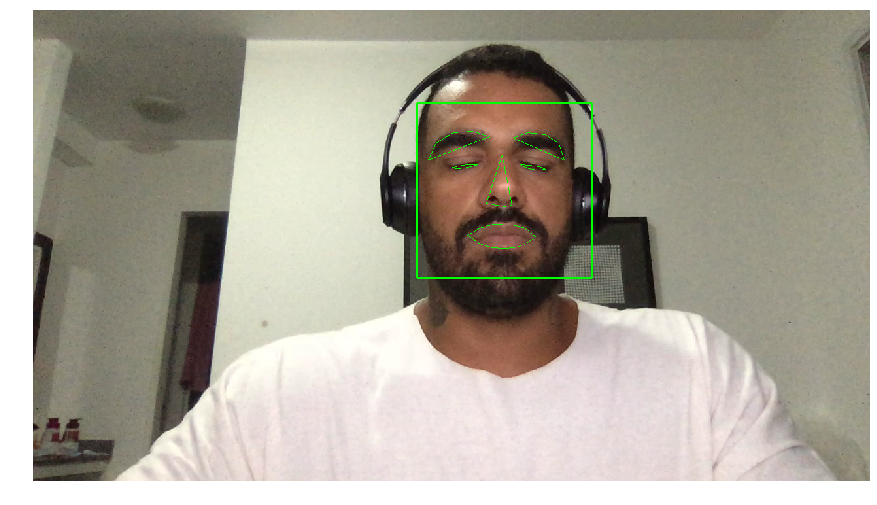

In [9]:
exibir_imagem("images/evidence/closed-eyes-matched.png")

## 6. Descritor de objetos na cena

A organização do local na casa do entrevistado é um item relevante, pois a partir destes detalhes é possível traçar alguns tipos de perfis que são essenciais para certas posições nas empresas.

Desta forma precisamos construir um algoritmo que realize uma inspeção de objetos na área da câmera que é utilizada para fazer a entrevista. Ao final mostre quais e quantos objetos foram detectados.

É necessário baixar os pesos (modelo de deep-learning) neste link https://pjreddie.com/media/files/yolov3.weights e copiar para  pasta weights.

In [3]:
from utils import *
from darknet import Darknet

# Configurações na rede neural YOLOv3
cfg_file = 'cfg/yolov3.cfg'
m = Darknet(cfg_file)

# Pesos pré-treinados
weight_file = 'cfg/yolov3.weights'
m.load_weights(weight_file)

# Rótulos de classes
namesfile = 'data/coco.names'
class_names = load_class_names(namesfile)

Ajuste os valores de NMS (_Non-Maximum Supression_) para regular a sensibilidade de imagens com baixa luminosidade e IOU (_Intersect of Union_) que definie o indicador se o retângulo de identificação de imagem foi adequadamente desenhado.

In [4]:
# SOLUCAO A SEGUIR
nms_thresh = 0.08
iou_thresh = 0.5

Separe um imagem que será analisada pelo classificador, após teclar o _Enter_. Armazene no arquivo ```images/evidence/interview-location.png```.

In [5]:
cam_capture = cv2.VideoCapture(0)

while True:
    ret, frame = cam_capture.read()
    
    if ret:
        cv2.imshow("Local inspection", frame)
        
        # SOLUCAO A SEGUIR
        if cv2.waitKey(1) == 13:
            cv2.imwrite("images/evidence/interview-location.png", frame)
            break
        
cam_capture.release()
cv2.destroyAllWindows()

A imagem a ser analisada.

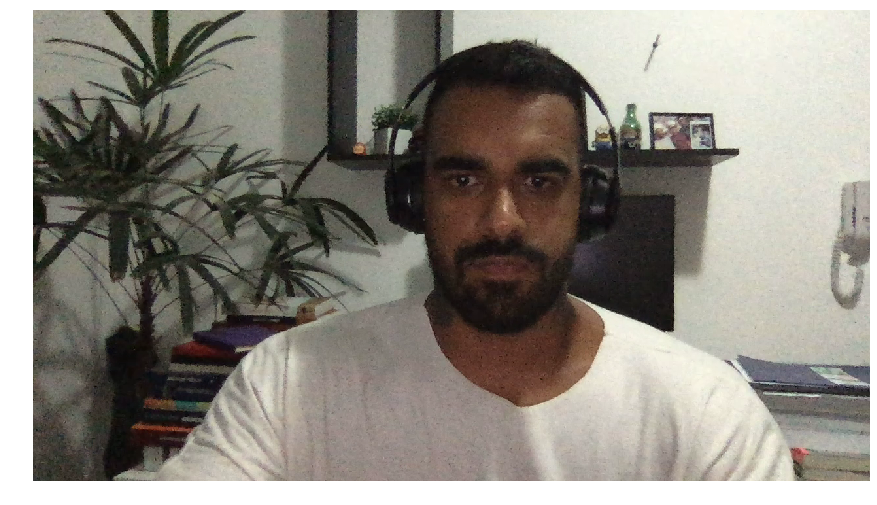

In [6]:
# SOLUCAO A SEGUIR
exibir_imagem("images/evidence/interview-location.png")

Os passos abaixo são para configuração da imagem no padrão que o classificador foi treinado.

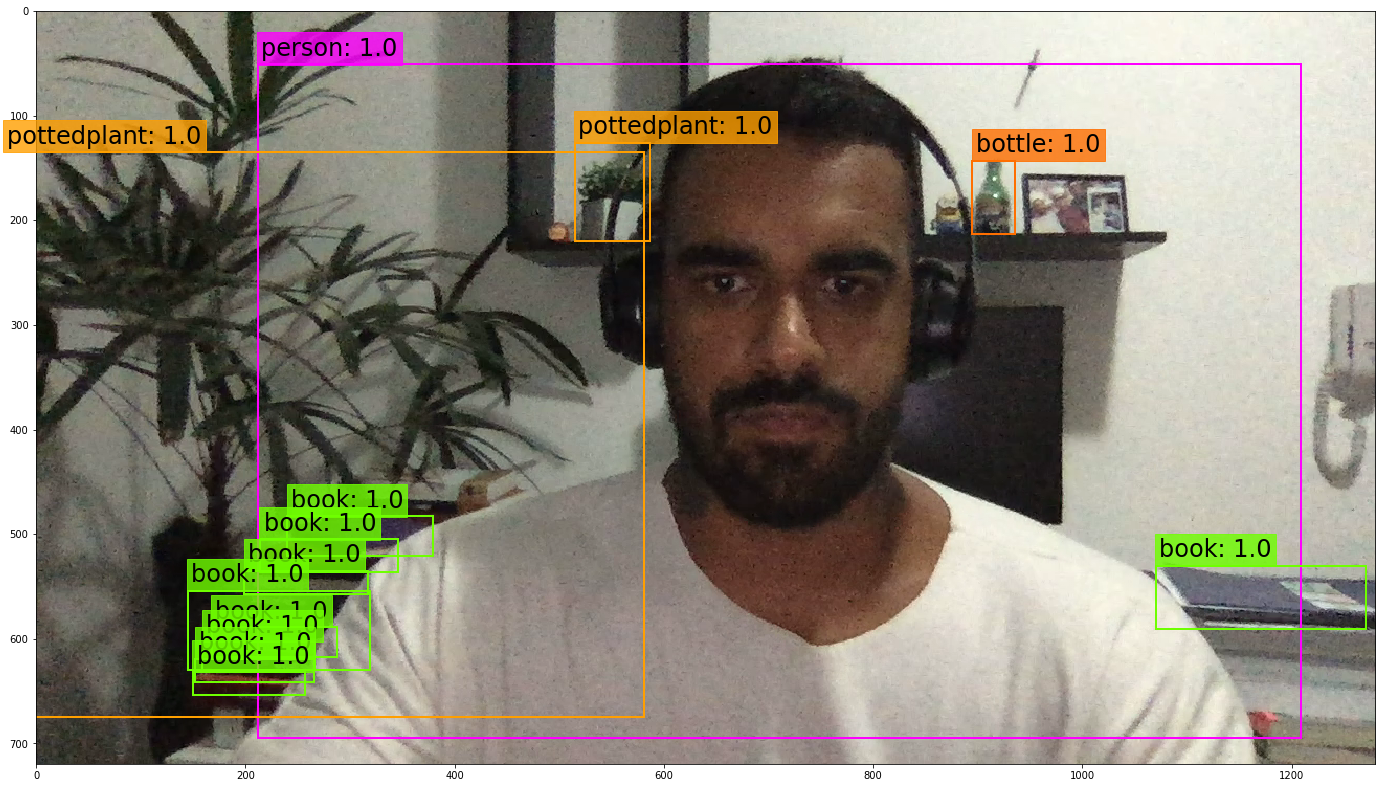

In [5]:
# Definindo tamnaho do gráfico
plt.rcParams['figure.figsize'] = [24.0, 14.0]

# Carregar imagem para classificação
img = cv2.imread("images/evidence/interview-location.png")

# Conversão para o espaço RGB
original_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Redimensionamento para adatapção da primeira camada da rede neural 
resized_image = cv2.resize(original_image, (m.width, m.height))

# Deteteção de objetos na imagem
boxes = detect_objects(m, resized_image, iou_thresh, nms_thresh)

# Desenho no gráfico com os regângulos e rótulos
plot_boxes(original_image, boxes, class_names, plot_labels = True)

Obtenha os objetos identificados a partir da função ```list_objects(boxes, class_names)```. Será retornardo uma lista de objetos que deverá ser analisado para contar a quantidade de cada objeto. Se houver mais de um item igual, por exemplo _tvmonitor_ ele aparecerá duplicado na imagem.

In [9]:
# IMPLEMENTAR
# Conte os objetos identificados pelo classificador, de forma que seja exibido 
# object 1, quantity 1
# object 2, quantity 1
# ...

from collections import Counter

objects = list_objects(boxes, class_names)
objects_counter = Counter(objects)
for name, quantity in objects_counter.items():
    print("object {0}, quantity {1}".format(name, quantity))

object person, quantity 1
object pottedplant, quantity 2
object bottle, quantity 1
object book, quantity 9


## Conclusões finais

**Pergunta:** Diante de todos os desafios propostos (1 ao 6) e soluções encontradas, quais seriam os próximos passos de forma a tornar mais precisos cada atividade, levando em consideração: (1) restrições de processamento em tempo real, (2) sem restrições de processamento em tempo real?

**Resposta**:

A partir da descrição do problema, é inferido que a solução deverá ser utilizada por múltiplos usuários. No contexto de processamento em tempo real, é interessante tratar da quantidade de frames que serão analisados de forma a criar uma solução que seja escalável e que consiga atender aos múltiplos usuários da aplicação concorrentemente. Em geral, o tratamento e processamento de imagens tem alto custo computacional; ter esta característica em mente ao arquiteturar uma solução escalável para este problema faz-se necessário.

No desafio 2, a obtenção da base de treinamento mostrou-se bastante lento (em um MacBook Pro 2017). No contexto de uma solução multi-usuário que precisa atender o requisito de processamento em tempo real, este fato poderá ser um gargalo. Além disso, estabelecer meios de armazenamento escalável das imagens também é necessário, a fim de manter uma base de dados que seja otimizável.

Nos desafios 3, 4 e 5, são utilizados parâmetros que precisaram ser ajustados ao usuário de forma a atender às especificidades da face sendo analisada; em geral, não obtemos resultados igualmente esperados e de qualidade com os valores paramétricos estabelecidos para todos os tipos de face. Encontrar uma maneira de obter bons resultados, tanto em processamento em tempo real ou não, faz-se importante para estabelecer uma solução que seja inclusiva e que consiga abranger a diversidade de usuários que utilizarão a solução.